### 1. Setup e Imports

In [1]:
import json as _json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import sys
from pathlib import Path

# Agregar path del proyecto para imports
sys.path.append(os.path.abspath('../../..'))
from sae.tools.naming_utils import save_checkpoint, get_model_name, get_extras_id, get_checkpoint_dir
from sae.tools.experiment_utils import get_experiment_dir, get_plots_dir, get_metrics_dir, get_report_name

# Configuración de visualización para Quarto/PDF
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', None)
np.set_printoptions(linewidth=100, precision=4, suppress=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')


Dispositivo: cuda


### 2 Metadata para Naming de Checkpoints

In [2]:
# Metadata para naming de checkpoints
NAMING_META = {
    'variante': 'topk',              # Arquitectura del SAE
    'tecnica': 'batch-topk',               # BatchTopK
    'capa': 6,                       # Layer del modelo OthelloGPT
    'juegos': 25000,                   # Número de partidas
    'base_path': 'C:\\Users\\Esposa\\Documents\\Repos\\sae-othello-gpt',
    'experiment_base_path': os.path.abspath('../../../experiments'),
    'extras': {
        'expansion': 16,   # d_sae / d_in = 8192 / 512
        'k': 50,           # número de features activas L0 promedio ≈ k
        'epochs': 1000,
        'patience': 20,
        'batch_size_tokens': 1024,
    }
}

print('\nMetadata de naming:')
for key, value in NAMING_META.items():
    print(f'  {key}: {value}')



Metadata de naming:
  variante: topk
  tecnica: batch-topk
  capa: 6
  juegos: 25000
  base_path: C:\Users\Esposa\Documents\Repos\sae-othello-gpt
  experiment_base_path: c:\Users\Esposa\Documents\Repos\othello_world\sae\experiments
  extras: {'expansion': 16, 'k': 50, 'epochs': 1000, 'patience': 20, 'batch_size_tokens': 1024}


In [3]:
extras_id = get_extras_id(
    get_checkpoint_dir(
        NAMING_META['base_path'],
        NAMING_META['variante'],
        NAMING_META['tecnica'],
        NAMING_META['capa'],
        NAMING_META['juegos']
    ),
    NAMING_META['extras']
) if NAMING_META.get('extras') else None

# get_plots_dir crea el directorio automáticamente
plots_dir = Path(get_plots_dir(
    NAMING_META['experiment_base_path'],
    NAMING_META['variante'],
    NAMING_META['tecnica'],
    NAMING_META['capa'],
    NAMING_META['juegos'],
    extras_id=extras_id
))

print(f'extras_id: {extras_id}')
print(f'plots_dir: {plots_dir}')

✓ Nuevo extras registrado: ex4 → {'expansion': 16, 'k': 50, 'epochs': 1000, 'patience': 20, 'batch_size_tokens': 1024}
extras_id: ex4
plots_dir: c:\Users\Esposa\Documents\Repos\othello_world\sae\experiments\layer_06\sae_topk\sae_batch-topk_topk\25000games\ex4\plots


### 3. Configuración del SAE con SAELens

Configuración usando `LanguageModelSAERunnerConfig` de SAELens con `architecture='batchtopk'`.

**Arquitectura BatchTopK:**
- **BatchTopK activation**: calcula un threshold global por batch para que el **promedio** de features activas por muestra sea `k` (L0 promedio ≈ k, pero varía por muestra)
- **Sin coeficiente de sparsidad**: la sparsity se controla directamente con `k`
- **Loss = MSE únicamente** (sin penalización L1)

| Parámetro | L1 (standard) | TopK | BatchTopK |
|-----------|:---:|:---:|:---:|
| Sparsity | `sparsity_coef` (soft) | `k` (hard, por muestra) | `k` (promedio del batch) |
| L0 | Variable | Fijo = k por muestra | Variable por muestra, promedio ≈ k |
| Loss | MSE + λ·L1 | MSE | MSE |

> **Nota sobre el runner**: `LanguageModelSAETrainingRunner(cfg).run()` requiere que Othello-GPT
> esté cargado vía TransformerLens. Las celdas siguientes entrenan el SAE directamente sobre los
> archivos `.npy` pre-extraídos usando la arquitectura BatchTopK definida en el config.

In [4]:
NUM_EPOCHS = NAMING_META['extras']['epochs']

cfg = {
    'architecture':          'batchtopk',
    'd_in':                  512,
    'd_sae':                 8192,
    'k':                     50,
    'lr':                    1e-3,
    'train_batch_size_tokens': 1024,
    'hook_name':             'blocks.5.hook_resid_post',
}

cfg_summary = pd.DataFrame({
    'Parámetro SAELens': ['architecture', 'd_in', 'd_sae', 'k (L0 promedio)', 'hook_name', 'lr'],
    'Valor': [cfg['architecture'], cfg['d_in'], cfg['d_sae'], cfg['k'],
              cfg['hook_name'], cfg['lr']]
})
print('Configuración SAELens:')
print(cfg_summary.to_string(index=False))

Configuración SAELens:
Parámetro SAELens                    Valor
     architecture                batchtopk
             d_in                      512
            d_sae                     8192
  k (L0 promedio)                       50
        hook_name blocks.5.hook_resid_post
               lr                    0.001


### 4. Dataset de Activaciones (Train/Validation Split 80-20%)

Activaciones pre-extraídas con `sae/activations/run_extraction.py` desde la capa `blocks.5.hook_resid_post`.


In [5]:
class ActivationsDataset(Dataset):
    """Dataset para cargar activaciones extraídas"""
    def __init__(self, activations_path):
        self.activations = np.load(activations_path)
    def __len__(self):
        return len(self.activations)
    def __getitem__(self, idx):
        return torch.tensor(self.activations[idx], dtype=torch.float32)

activations_file = Path(f"../../../activations/data/layer{NAMING_META['capa']}_{NAMING_META['juegos']}games.npy")
full_dataset = ActivationsDataset(activations_file)

# Split 80-20 reproducible
train_size = int(0.8 * len(full_dataset))
val_size   = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=cfg["train_batch_size_tokens"])
val_loader   = DataLoader(val_dataset,   batch_size=cfg["train_batch_size_tokens"])

dataset_info = pd.DataFrame({
    'Conjunto': ['Train', 'Validación', 'Total'],
    'Muestras': [f'{len(train_dataset):,}', f'{len(val_dataset):,}', f'{len(full_dataset):,}'],
    'Shape':    [str(full_dataset.activations.shape), '', ''],
})
print(dataset_info.to_string(index=False))


  Conjunto  Muestras          Shape
     Train 1,180,000 (1475000, 512)
Validación   295,000               
     Total 1,475,000               


### 5. Modelo: BatchTopK SAE

Implementación de la arquitectura BatchTopK de SAELens.

**Diferencia clave vs ReLU + L1 y vs TopK estándar:**
- El encoder proyecta a `d_sae=8192` dimensiones (pre-activación)
- La activación **BatchTopK** calcula un threshold global del batch (k-ésimo valor promediado); cada muestra puede tener más o menos de `k` features activas
- L0 es **variable por muestra**, pero el **promedio del batch ≈ k** (soft constraint a nivel de batch)
- No hay `sparsity_coef` ni cosine annealing
- El decoder se normaliza a norma unitaria después de cada paso del optimizador

In [6]:
class BatchTopKSAE(nn.Module):
    """
    Sparse Autoencoder con activación BatchTopK.
    Equivalente a SAELens architecture='batchtopk'.

    Encoder    : d_in -> d_sae  (lineal + pre-bias centering)
    Activación : BatchTopK  (mantiene el promedio de k features activas por batch)
    Decoder    : d_sae -> d_in  (columnas con norma unitaria)
    """
    def __init__(self, d_in: int, d_sae: int, k: int, k_aux: int = 512):
        super().__init__()
        self.d_in  = d_in
        self.d_sae = d_sae
        self.k     = k
        self.k_aux = k_aux

        self.W_enc = nn.Parameter(torch.empty(d_in, d_sae))
        self.W_dec = nn.Parameter(torch.empty(d_sae, d_in))
        self.b_dec = nn.Parameter(torch.zeros(d_in))

        nn.init.kaiming_uniform_(self.W_enc)
        nn.init.kaiming_uniform_(self.W_dec)
        self.W_dec.data = self.W_dec.data / self.W_dec.data.norm(dim=-1, keepdim=True)
        self.register_buffer('num_batches_not_active', torch.zeros(d_sae))
        self.n_batches_to_dead = 10  # latente muerto si inactivo por 10 batches seguidos

    def encode(self, x: torch.Tensor, threshold=None) -> torch.Tensor:
        """Proyecta a espacio latente con activación BatchTopK"""
        x_cent   = x - self.b_dec
        pre_acts = F.relu(x_cent @ self.W_enc)
        return self._topk_activation(pre_acts, threshold=threshold)

    def _topk_activation(self, x: torch.Tensor, threshold=None) -> torch.Tensor:
        """BatchTopK: selecciona exactamente k * batch_size activaciones usando scatter."""
        if threshold is None:
            acts_topk = torch.topk(x.flatten(), self.k * x.shape[0], dim=-1)
            return (
                torch.zeros_like(x.flatten())
                .scatter(-1, acts_topk.indices, acts_topk.values)
                .reshape(x.shape)
            )
        return torch.where(x > threshold, x, torch.zeros_like(x))

    def decode(self, hidden: torch.Tensor) -> torch.Tensor:
        return hidden @ self.W_dec + self.b_dec

    def preprocess_input(self, x: torch.Tensor):
        x_mean = x.mean(dim=-1, keepdim=True)
        x = x - x_mean
        x_std = x.std(dim=-1, keepdim=True)
        x = x / (x_std + 1e-5)
        return x, x_mean, x_std

    def postprocess_output(self, x_reconstruct: torch.Tensor,
                          x_mean: torch.Tensor, x_std: torch.Tensor) -> torch.Tensor:
        return x_reconstruct * x_std + x_mean

    def forward(self, x: torch.Tensor, threshold=None):
        x_norm, x_mean, x_std = self.preprocess_input(x)
        x_cent   = x_norm - self.b_dec
        pre_acts = F.relu(x_cent @ self.W_enc)
        hidden   = self._topk_activation(pre_acts, threshold=threshold)
        recon    = self.postprocess_output(self.decode(hidden), x_mean, x_std)
        return recon, hidden, pre_acts

    def auxiliary_loss(self, x: torch.Tensor, x_reconstruct: torch.Tensor, acts: torch.Tensor) -> torch.Tensor:
        """L_aux del repo oficial: reconstruye el residual con top-k_aux dead latents."""
        dead_features = self.num_batches_not_active >= self.n_batches_to_dead
        if dead_features.sum() == 0:
            return torch.tensor(0.0, device=x.device)
        residual = x.float() - x_reconstruct.float()
        acts_topk_aux = torch.topk(
            acts[:, dead_features],
            min(self.k_aux, int(dead_features.sum().item())),
            dim=-1,
        )
        acts_aux = torch.zeros_like(acts[:, dead_features]).scatter(
            -1, acts_topk_aux.indices, acts_topk_aux.values
        )
        x_reconstruct_aux = acts_aux @ self.W_dec[dead_features]
        return (1/32) * (x_reconstruct_aux.float() - residual.float()).pow(2).mean()

    @torch.no_grad()
    def update_inactive_features(self, acts):
        self.num_batches_not_active += (acts.sum(0) == 0).float()
        self.num_batches_not_active[acts.sum(0) > 0] = 0

    @torch.no_grad()
    def estimate_threshold(self, loader, device, n_batches: int = 10) -> float:
        """Estima un threshold estable promediando sobre múltiples batches
           (independiente del batch actual — para usar en validación/inferencia)."""
        self.eval()
        thresholds = []
        for i, batch in enumerate(loader):
            if i >= n_batches:
                break
            x        = batch.to(device)
            x_norm, _, _ = self.preprocess_input(x)
            x_cent   = x_norm - self.b_dec
            pre_acts = F.relu(x_cent @ self.W_enc)
            mins = []
            for sample_idx in range(pre_acts.shape[0]):
                pos = pre_acts[sample_idx][pre_acts[sample_idx] > 0]
                if pos.numel() > 0:
                    mins.append(pos.min().item())
            t = float(np.mean(mins)) if mins else 0.0
            thresholds.append(t)
        return float(np.mean(thresholds))

    @torch.no_grad()
    def make_decoder_weights_and_grad_unit_norm(self):
        """Proyecta el gradiente del decoder y renormaliza — igual que el repo oficial."""
        W_dec_normed = self.W_dec / self.W_dec.norm(dim=-1, keepdim=True)
        W_dec_grad_proj = (self.W_dec.grad * W_dec_normed).sum(-1, keepdim=True) * W_dec_normed
        self.W_dec.grad -= W_dec_grad_proj
        self.W_dec.data = W_dec_normed


# Crear modelo desde parámetros del cfg SAELens
model = BatchTopKSAE(d_in=cfg['d_in'], d_sae=cfg['d_sae'], k=cfg['k']).to(device)
num_params = sum(p.numel() for p in model.parameters())

model_info = pd.DataFrame({
    'Componente': [
        'Input', 'Encoder (W_enc)', 'Activación', 'Hidden activos', 'Decoder (W_dec)', 'Output',
        'k_aux', 'Total params'
    ],
    'Dimensión': [
        f'{cfg["d_in"]}',
        f'{cfg["d_in"]} -> {cfg["d_sae"]}',
        f'BatchTopK (k={cfg["k"]})',
        f'{cfg["d_sae"]} (solo {cfg["k"]} activos en promedio)',
        f'{cfg["d_sae"]} -> {cfg["d_in"]}',
        f'{cfg["d_in"]}',
        f'{model.k_aux}',
        f'{num_params:,}'
    ]
})
print(model_info.to_string(index=False))

     Componente                          Dimensión
          Input                                512
Encoder (W_enc)                        512 -> 8192
     Activación                   BatchTopK (k=50)
 Hidden activos 8192 (solo 50 activos en promedio)
Decoder (W_dec)                        8192 -> 512
         Output                                512
          k_aux                                512
   Total params                          8,389,120


### 6. Función de Pérdida BatchTopK

**Loss = MSE(reconstrucción)**

- **MSE**: error de reconstrucción (igual que en L1)
- **Sin L1 penalty**: la sparsity ya está controlada por el threshold global de BatchTopK
- No hay `sparsity_coef` ni annealing — el único hiperparámetro de sparsity es `k` (promedio del batch)

In [7]:
ALPHA_AUX = 1 / 32  # peso de la pérdida auxiliar (arXiv:2412.06410)

def loss_function(x, reconstruction, acts, model):
    """
    Pérdida BatchTopK: MSE + alpha * L_aux  (arXiv:2412.06410).
    - MSE    : error de reconstrucción
    - L_aux  : reconstruye el residual con las top-k_aux features para
               evitar features muertas (alpha = 1/32)

    Args:
        x:              Activaciones originales
        reconstruction: Activaciones reconstruidas
        acts:           Pre-activaciones del encoder
        model:          Instancia de BatchTopKSAE
    Returns:
        total_loss (scalar)
    """
    mse   = F.mse_loss(reconstruction, x)
    l_aux = model.auxiliary_loss(x, reconstruction, acts)
    return mse + l_aux


optimizer = torch.optim.Adam(model.parameters(), lr=cfg["lr"], betas=(0.9, 0.99))

optim_info = pd.DataFrame({
    'Parámetro': ['Optimizador', 'Learning rate', 'betas', 'k (L0 promedio ≈ k)', 'k_aux', 'alpha_aux'],
    'Valor':     ['Adam', cfg["lr"], '(0.9, 0.99)', cfg["k"], model.k_aux, f'{ALPHA_AUX:.5f} (1/32)']
})
print(optim_info.to_string(index=False))

          Parámetro          Valor
        Optimizador           Adam
      Learning rate          0.001
              betas    (0.9, 0.99)
k (L0 promedio ≈ k)             50
              k_aux            512
          alpha_aux 0.03125 (1/32)


### 7. Loop de Entrenamiento

In [8]:
PATIENCE  = NAMING_META['extras']['patience']

save_dir = Path('./saved_model')
save_dir.mkdir(exist_ok=True)
best_model_name = get_model_name(
    variante=NAMING_META['variante'],
    tecnica=NAMING_META['tecnica'],
    capa=NAMING_META['capa'],
    juegos=NAMING_META['juegos'],
    estado='best',
    extras_id=extras_id
)
BEST_CKPT = save_dir / best_model_name

history = {
    'train_mse_loss':        [],
    'train_l0_sparsity':     [],
    'train_fraction_active': [],
    'val_mse_loss':          [],
    'val_l0_sparsity':       [],
    'val_fraction_active':   [],
}

best_val_mse      = float('inf')
best_epoch        = 0
epochs_no_improve = 0

print(f'Iniciando entrenamiento: {NUM_EPOCHS} épocas máximo')
print(f'Early stopping: patience={PATIENCE}')
print(f'k = {cfg["k"]} features activas (L0 promedio ≈ k por batch)')
print(f'k_aux = {model.k_aux} | alpha_aux = {ALPHA_AUX:.5f} (1/32)')
print(f'Best checkpoint: {BEST_CKPT}')
print('=' * 70)

for epoch in range(NUM_EPOCHS):

    # TRAIN
    model.train()
    t_mse = t_l0 = t_frac = 0.0

    for batch in train_loader:
        x = batch.to(device)
        optimizer.zero_grad()
        recon, hidden, pre_acts = model(x)
        total_loss = loss_function(x, recon, pre_acts, model)
        total_loss.backward()
        model.make_decoder_weights_and_grad_unit_norm()
        optimizer.step()
        model.update_inactive_features(hidden)

        with torch.no_grad():
            t_mse  += F.mse_loss(recon, x).item()
            t_l0   += (hidden > 0).float().sum(dim=1).mean().item()
            t_frac += (hidden > 0).float().mean().item()

    n = len(train_loader)
    history['train_mse_loss'].append(t_mse / n)
    history['train_l0_sparsity'].append(t_l0 / n)
    history['train_fraction_active'].append(t_frac / n)

    # VALIDATION (sin threshold — igual que training, L0 ≈ k)
    model.eval()
    v_mse = v_l0 = v_frac = 0.0

    with torch.no_grad():
        for batch in val_loader:
            x = batch.to(device)
            recon, hidden, _ = model(x)
            v_mse  += F.mse_loss(recon, x).item()
            v_l0   += (hidden > 0).float().sum(dim=1).mean().item()
            v_frac += (hidden > 0).float().mean().item()

    nv = len(val_loader)
    history['val_mse_loss'].append(v_mse / nv)
    history['val_l0_sparsity'].append(v_l0 / nv)
    history['val_fraction_active'].append(v_frac / nv)

    print(f"Época {epoch+1:3d}/{NUM_EPOCHS} | "
          f"Train MSE: {history['train_mse_loss'][-1]:.6f} | "
          f"Val MSE: {history['val_mse_loss'][-1]:.6f} | "
          f"Train L0: {history['train_l0_sparsity'][-1]:.1f} | "
          f"Val L0: {history['val_l0_sparsity'][-1]:.1f}")

    # Early stopping
    if history['val_mse_loss'][-1] < best_val_mse:
        best_val_mse      = history['val_mse_loss'][-1]
        best_epoch        = epoch + 1
        epochs_no_improve = 0

        torch.save(model.state_dict(), BEST_CKPT)
        save_checkpoint(
            model,
            base_path=NAMING_META['base_path'],
            variante=NAMING_META['variante'],
            tecnica=NAMING_META['tecnica'],
            capa=NAMING_META['capa'],
            juegos=NAMING_META['juegos'],
            estado='best',
            extras=NAMING_META['extras'],
            config=cfg,
            history=history,
            optimizer=optimizer
        )
        print(f'  Mejor modelo guardado (época {best_epoch} | Val MSE: {best_val_mse:.6f})')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f'\nEarly stopping en época {epoch+1} (mejor: época {best_epoch})')
            break

# Restaurar mejor modelo
model.load_state_dict(torch.load(BEST_CKPT, weights_only=True))
print(f'\nMejor época: {best_epoch} | Mejor Val MSE: {best_val_mse:.6f}')

# Estimar threshold de inferencia al final del entrenamiento
inference_threshold = model.estimate_threshold(train_loader, device, n_batches=10)
print(f'Threshold de inferencia estimado: {inference_threshold:.4f}')

Iniciando entrenamiento: 1000 épocas máximo
Early stopping: patience=20
k = 50 features activas (L0 promedio ≈ k por batch)
k_aux = 512 | alpha_aux = 0.03125 (1/32)
Best checkpoint: saved_model\sae_topk_batch-topk_l6_25000g_ex4_best.pt
Época   1/1000 | Train MSE: 0.229684 | Val MSE: 0.186812 | Train L0: 50.0 | Val L0: 50.0
✓ Checkpoint guardado: C:\Users\Esposa\Documents\Repos\sae-othello-gpt\layer_06\models\sae_topk\sae_batch-topk_topk\25000games\sae_topk_batch-topk_l6_25000g_ex4_best.pt
  Mejor modelo guardado (época 1 | Val MSE: 0.186812)
Época   2/1000 | Train MSE: 0.179167 | Val MSE: 0.175371 | Train L0: 50.0 | Val L0: 50.0
✓ Checkpoint guardado: C:\Users\Esposa\Documents\Repos\sae-othello-gpt\layer_06\models\sae_topk\sae_batch-topk_topk\25000games\sae_topk_batch-topk_l6_25000g_ex4_best.pt
  Mejor modelo guardado (época 2 | Val MSE: 0.175371)
Época   3/1000 | Train MSE: 0.170560 | Val MSE: 0.170190 | Train L0: 50.0 | Val L0: 50.0
✓ Checkpoint guardado: C:\Users\Esposa\Documents\Re

### 8. Guardar Modelo

In [9]:
# Guardar checkpoint final
checkpoint = {
    'model_state_dict':     model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'config': {
        'architecture': cfg["architecture"],
        'd_in':         cfg["d_in"],
        'd_sae':        cfg["d_sae"],
        'k':            cfg["k"],
        'lr':           cfg["lr"],
        'hook_name':    cfg["hook_name"],
    },
    'history': history,
}

final_model_name = get_model_name(
    variante=NAMING_META['variante'],
    tecnica=NAMING_META['tecnica'],
    capa=NAMING_META['capa'],
    juegos=NAMING_META['juegos'],
    estado='final',
    extras_id=extras_id
)
checkpoint_path = save_dir / final_model_name
torch.save(checkpoint, checkpoint_path)
print(f'Modelo guardado: {checkpoint_path}')

save_checkpoint(
    model,
    base_path=NAMING_META['base_path'],
    variante=NAMING_META['variante'],
    tecnica=NAMING_META['tecnica'],
    capa=NAMING_META['capa'],
    juegos=NAMING_META['juegos'],
    estado='final',
    extras=NAMING_META['extras'],
    config=cfg,
    history=history,
    optimizer=optimizer
)

Modelo guardado: saved_model\sae_topk_batch-topk_l6_25000g_ex4_final.pt
✓ Checkpoint guardado: C:\Users\Esposa\Documents\Repos\sae-othello-gpt\layer_06\models\sae_topk\sae_batch-topk_topk\25000games\sae_topk_batch-topk_l6_25000g_ex4_final.pt


WindowsPath('C:/Users/Esposa/Documents/Repos/sae-othello-gpt/layer_06/models/sae_topk/sae_batch-topk_topk/25000games/sae_topk_batch-topk_l6_25000g_ex4_final.pt')

### 9. Métricas básicas del modelo

In [10]:
import json

metrics_dir = get_metrics_dir(
    NAMING_META['experiment_base_path'],
    NAMING_META['variante'],
    NAMING_META['tecnica'],
    NAMING_META['capa'],
    NAMING_META['juegos'],
    extras_id=extras_id
)

training_metrics = {
    # Calidad de reconstrucción
    'val_mse_final':             history['val_mse_loss'][-1],
    'val_mse_best':              best_val_mse,
    'val_l0_final':              history['val_l0_sparsity'][-1],
    'val_fraction_active_final': history['val_fraction_active'][-1],
    # Contexto del entrenamiento
    'best_epoch':                best_epoch,
    'total_epochs':              len(history['train_mse_loss']),
    'train_mse_final':           history['train_mse_loss'][-1],
    'train_l0_final':            history['train_l0_sparsity'][-1],
    # Hiperparámetros TopK
    'architecture':              cfg["architecture"],
    'k':                         cfg["k"],
    'd_sae':                     cfg["d_sae"],
    'd_in':                      cfg["d_in"],
    'expansion_factor':          cfg["d_sae"] // cfg["d_in"],
    'hook_name':                 cfg["hook_name"],
}

os.makedirs(metrics_dir, exist_ok=True)
metrics_path = Path(metrics_dir) / 'training_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(training_metrics, f, indent=2)

print(f'Métricas guardadas: {metrics_path}')
print(pd.DataFrame(
    list(training_metrics.items()), columns=['Métrica', 'Valor']
).to_string(index=False))


Métricas guardadas: c:\Users\Esposa\Documents\Repos\othello_world\sae\experiments\layer_06\sae_topk\sae_batch-topk_topk\25000games\ex4\metrics\training_metrics.json
                  Métrica                    Valor
            val_mse_final                 0.162248
             val_mse_best                 0.161771
             val_l0_final                     50.0
val_fraction_active_final                 0.006104
               best_epoch                       29
             total_epochs                       49
          train_mse_final                 0.154207
           train_l0_final                     50.0
             architecture                batchtopk
                        k                       50
                    d_sae                     8192
                     d_in                      512
         expansion_factor                       16
                hook_name blocks.5.hook_resid_post


### 10. Visualización de Resultados

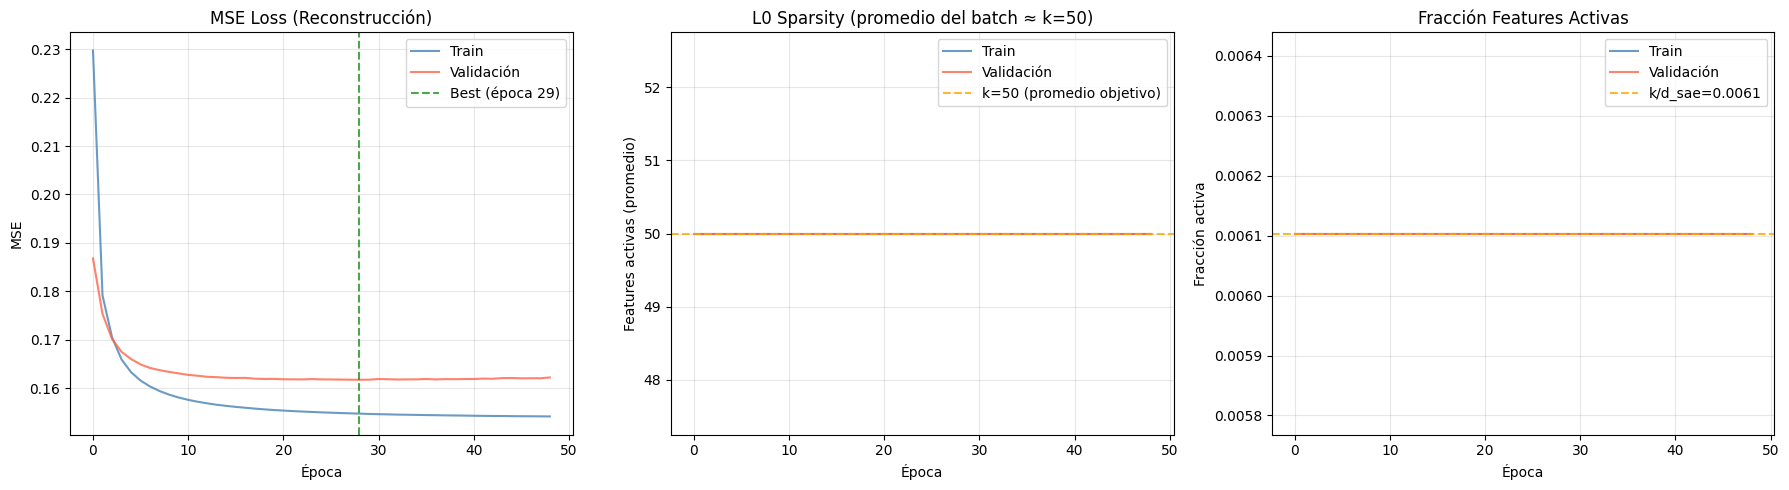


Gráficas guardadas exitosamente


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MSE Loss
axes[0].plot(history['train_mse_loss'], label='Train', color='steelblue', alpha=0.8)
axes[0].plot(history['val_mse_loss'],   label='Validación', color='tomato', alpha=0.8)
if best_epoch > 0:
    axes[0].axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.7,
                    label=f'Best (época {best_epoch})')
axes[0].set_title('MSE Loss (Reconstrucción)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# L0 sparsity  (para BatchTopK el promedio del batch ≈ k, pero varía por muestra)
axes[1].plot(history['train_l0_sparsity'], label='Train', color='steelblue', alpha=0.8)
axes[1].plot(history['val_l0_sparsity'],   label='Validación', color='tomato', alpha=0.8)
axes[1].axhline(cfg["k"], color='orange', linestyle='--', alpha=0.8, label=f'k={cfg["k"]} (promedio objetivo)')
axes[1].set_title(f'L0 Sparsity (promedio del batch ≈ k={cfg["k"]})')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Features activas (promedio)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Fracción activa
axes[2].plot(history['train_fraction_active'], label='Train', color='steelblue', alpha=0.8)
axes[2].plot(history['val_fraction_active'],   label='Validación', color='tomato', alpha=0.8)
expected_frac = cfg["k"] / cfg["d_sae"]
axes[2].axhline(expected_frac, color='orange', linestyle='--', alpha=0.8,
                label=f'k/d_sae={expected_frac:.4f}')
axes[2].set_title('Fracción Features Activas')
axes[2].set_xlabel('Época')
axes[2].set_ylabel('Fracción activa')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(plots_dir / 'training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n' + '='*50)
print('Gráficas guardadas exitosamente')
print('='*50)

### 12. Generar PDF con Quarto

Una vez ejecutado todo el notebook, ejecutar el siguiente comando en la terminal para generar el PDF con Quarto:

In [12]:
import subprocess

exp_dir = get_experiment_dir(
    NAMING_META['experiment_base_path'],
    NAMING_META['variante'],
    NAMING_META['tecnica'],
    NAMING_META['capa'],
    NAMING_META['juegos'],
    extras_id=extras_id
)

pdf_name = get_report_name(
    NAMING_META['variante'],
    NAMING_META['tecnica'],
    NAMING_META['capa'],
    NAMING_META['juegos'],
    'training',
    extras_id=extras_id
)

notebook_name = 'train_sae_batch-topk.ipynb'
output_path = exp_dir / pdf_name

print(f'Generando PDF con Quarto...')
print(f'Archivo de salida: {output_path}')

result = subprocess.run(
    f'quarto render {notebook_name} --to pdf --output-dir "{exp_dir}" --output {pdf_name}',
    shell=True,
    capture_output=True,
    text=True
)

if result.returncode == 0:
    print(f'PDF generado exitosamente: {output_path}')
else:
    print(f'Error al generar PDF:')
    print(result.stderr)

Generando PDF con Quarto...
Archivo de salida: c:\Users\Esposa\Documents\Repos\othello_world\sae\experiments\layer_06\sae_topk\sae_batch-topk_topk\25000games\ex4\sae_topk_batch-topk_l6_25000g_ex4_training.pdf
PDF generado exitosamente: c:\Users\Esposa\Documents\Repos\othello_world\sae\experiments\layer_06\sae_topk\sae_batch-topk_topk\25000games\ex4\sae_topk_batch-topk_l6_25000g_ex4_training.pdf
